In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Example data
house_size = np.array([500, 800, 1000, 1200, 1500, 1800, 2000]).reshape(-1, 1)  # square feet
house_price = np.array([150000, 200000, 240000, 260000, 300000, 340000, 360000])  # dollars


In [2]:
# Create model
model = LinearRegression()

# Fit model
model.fit(house_size, house_price)

# Get slope and intercept
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (β1): {slope:.2f}")
print(f"Intercept (β0): {intercept:.2f}")

Slope (β1): 138.46
Intercept (β0): 90227.64


In [3]:
# Predict prices for the input sizes
predicted_price = model.predict(house_size)

# Example: predict price of a 1600 sqft house
new_size = np.array([[1600]])
print("Predicted price for 1600 sqft:", model.predict(new_size)[0])

Predicted price for 1600 sqft: 311756.0975609756


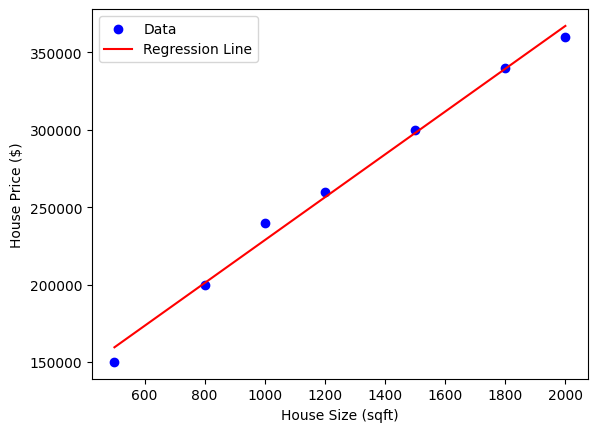

In [4]:
plt.scatter(house_size, house_price, color="blue", label="Data")
plt.plot(house_size, predicted_price, color="red", label="Regression Line")
plt.xlabel("House Size (sqft)")
plt.ylabel("House Price ($)")
plt.legend()
plt.show()

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Calculate metrics
mse = mean_squared_error(house_price, predicted_price)
rmse = np.sqrt(mse)
mae = mean_absolute_error(house_price, predicted_price)
r2 = r2_score(house_price, predicted_price)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.3f}")


RMSE: 6405.75
MAE: 5024.39
R²: 0.992


In [6]:
import statsmodels.api as sm

# Add constant (intercept) for statsmodels
X = sm.add_constant(house_size)  # adds β0 term
y = house_price

# Fit OLS regression
ols_model = sm.OLS(y, X).fit()

# Summary with coefficients, t-stats, p-values
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     586.4
Date:                Fri, 19 Sep 2025   Prob (F-statistic):           2.24e-06
Time:                        19:55:55   Log-Likelihood:                -71.287
No. Observations:                   7   AIC:                             146.6
Df Residuals:                       5   BIC:                             146.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9.023e+04   7737.946     11.660      0.0

C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


Shapiro-Wilk test statistic: 0.9639836348114779
p-value: 0.852094938536005
Residuals look normal (fail to reject H0).


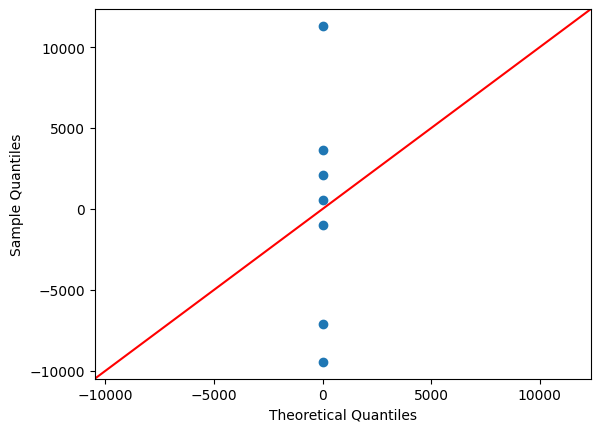

In [7]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Get residuals
residuals = ols_model.resid

# Shapiro-Wilk test
stat, p = shapiro(residuals)
print("Shapiro-Wilk test statistic:", stat)
print("p-value:", p)

if p > 0.05:
    print("Residuals look normal (fail to reject H0).")
else:
    print("Residuals are not normal (reject H0).")

# Q-Q plot
sm.qqplot(residuals, line='45')
plt.show()
